In [19]:
import pandas as pd
import matplotlib.pyplot as plt

In [20]:
file = pd.read_csv("TESS_M=0.4_RP=15.csv")

In [21]:
#stuff for HR diagram
color = file['phot_g_mean_mag'] - file['phot_rp_mean_mag']  # gaia color index (G - RP)
mag = file['phot_g_mean_mag']  # apparent magnitude

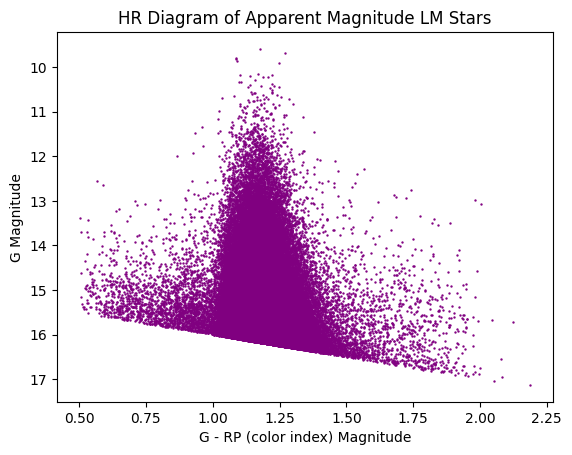

In [22]:
plt.gca().invert_yaxis() # invert since mag is flipped scale
plt.scatter(color, mag, s= 0.5, c='purple')
plt.xlabel("G - RP (color index) Magnitude")
plt.ylabel("G Magnitude")
plt.title("HR Diagram of Apparent Magnitude LM Stars")
plt.show()

In [23]:
#Notes
#G-mag, remember smaller number is dimmer, larger number brighter
#G-mag, "Gaia White Light", 330 - 1050 nm, the overal brightness
#RP-mag, "Gaia Red Photometer", 640 - 1050 nm, brightness in red/IR

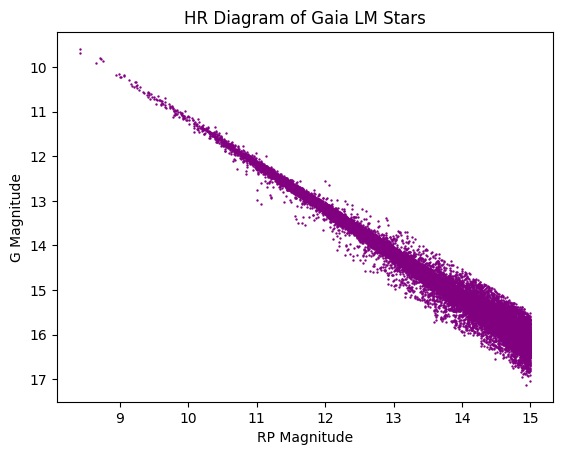

In [24]:
color = file['phot_rp_mean_mag'] #only G vs RP now
mag = file['phot_g_mean_mag']

plt.gca().invert_yaxis() # invert since mag is flipped scale
plt.scatter(color, mag, s= 0.5, c='purple')
plt.xlabel("RP Magnitude")
plt.ylabel("G Magnitude")
plt.title("HR Diagram of Gaia LM Stars")
plt.show()

In [10]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

In [16]:
# read data
file = pd.read_csv("TESS_M=0.4_RP=15.csv")

# x-axis color index for G - RP
#color = file['phot_g_mean_mag'] - file['phot_rp_mean_mag'] # ratio (-) of both filters, no dependence on d ; G - RP
# x-axis color index for G - J
#color = file['phot_g_mean_mag'] - file['Jmag']
# x-axis color index for G - K
color = file['phot_g_mean_mag'] - file['Kmag']

In [17]:
# y-axis absolute magnitude
# Gaia has parallax in mas
# d(pc) = 1/p("); as = mas/1000 ; d(pc) = 1/mas/1000 = 1000 / mas
distance_pc = 1000 / file['parallax'] # converted to as
gmag_ab = file['phot_g_mean_mag'] - 5 * np.log10(distance_pc) + 5 # convert to absolute mag ; G - 5log_10 d + 5

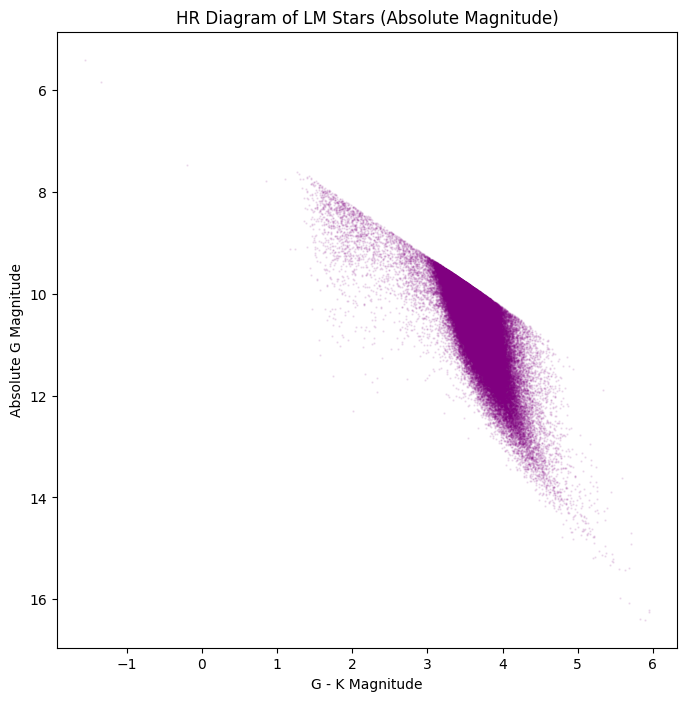

In [18]:
# HR plot
plt.figure(figsize=(8, 8))
plt.scatter(color, gmag_ab, s=0.5, alpha = 0.1, c='purple')

plt.gca().invert_yaxis() # magnitude scale is inverted
#plt.xlabel("G - RP (color index) Magnitude")
#plt.xlabel("G - J Magnitude")
plt.xlabel("G - K Magnitude")
plt.ylabel("Absolute G Magnitude")
plt.title("HR Diagram of LM Stars (Absolute Magnitude)")
plt.show()

Number of objects: 140813
Number of bins: 375


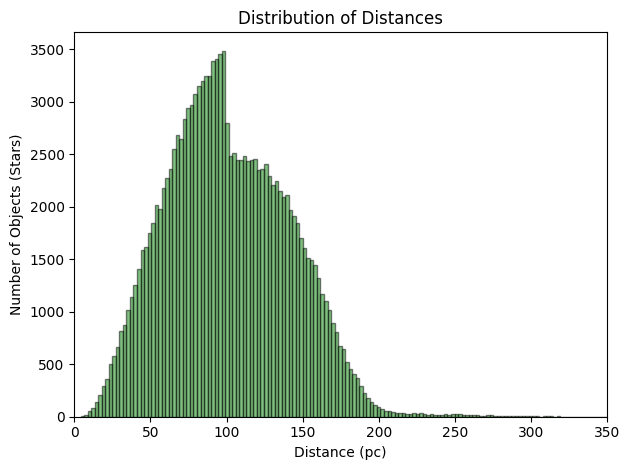

In [3]:
# number of objects
N = len(distance_pc)
print("Number of objects:", N)

# number of bins sqrt the number of objects
n_bins = int(np.sqrt(N))

print("Number of bins:", n_bins)

plt.hist(distance_pc, bins= n_bins, color= 'green', alpha= 0.5, edgecolor= 'black')
plt.xlabel("Distance (pc)")
plt.xlim(0,350)
plt.ylabel("Number of Objects (Stars)")
plt.title("Distribution of Distances")
plt.tight_layout()
plt.show()


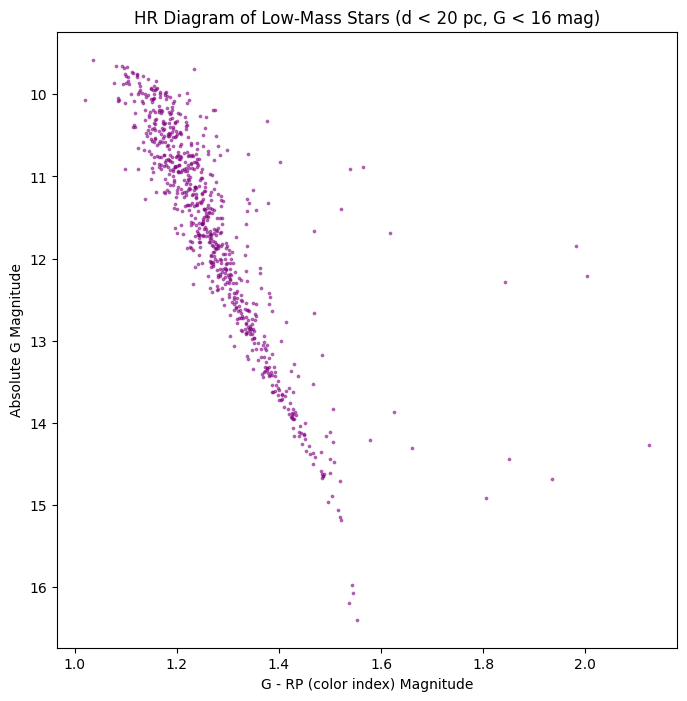

In [7]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# read data
file = pd.read_csv("TESS_M=0.4_RP=15.csv")

# distance conversion to pc 
file['distance_pc'] = 1000 / file['parallax']  # parallax in mas to distance in parsecs

# mask of magnitude limit from 0-16 and distance no greater than 20 pc
mask = (
    (file['phot_g_mean_mag'] > 0) &
    (file['phot_g_mean_mag'] < 16) &
    (file['distance_pc'] < 20)
)
file = file[mask]

#x-axis color index for G - RP
color = file['phot_g_mean_mag'] - file['phot_rp_mean_mag']
#x-axis color index for G - J Mag
#color = file['phot_g_mean_mag'] - file['Jmag']

# convert to absolute mag ; G - 5log_10 d + 5
gmag_ab = file['phot_g_mean_mag'] - 5 * np.log10(file['distance_pc']) + 5

# HR diagram plot
plt.figure(figsize=(8, 8))
plt.scatter(color, gmag_ab, s=3, alpha=0.5, c='purple')

plt.gca().invert_yaxis()  # magnitude scale is inverted
plt.xlabel("G - RP (color index) Magnitude")
plt.ylabel("Absolute G Magnitude")
plt.title("HR Diagram of Low-Mass Stars (d < 20 pc, G < 16 mag)")
plt.show()



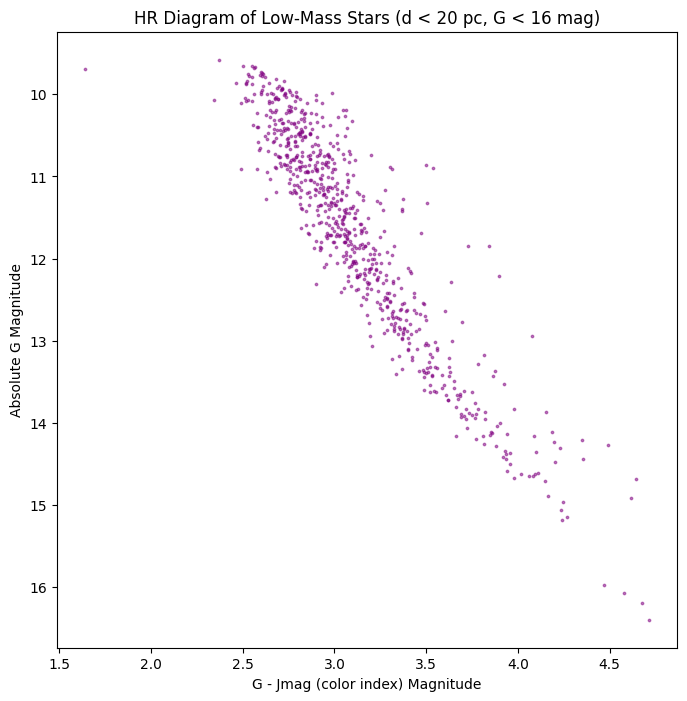

In [11]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# read data
file = pd.read_csv("TESS_M=0.4_RP=15.csv")

# distance conversion to pc 
file['distance_pc'] = 1000 / file['parallax']  # parallax in mas to distance in parsecs

# mask of magnitude limit from 0-16 and distance no greater than 20 pc
mask = (
    (file['phot_g_mean_mag'] > 0) &
    (file['phot_g_mean_mag'] < 16) &
    (file['distance_pc'] < 20)
)
file = file[mask]

#x-axis color index for G - J Mag
color = file['phot_g_mean_mag'] - file['Jmag'] # spans optical to IR; more sensitive to temperature 

# convert to absolute mag ; G - 5log_10 d + 5
gmag_ab = file['phot_g_mean_mag'] - 5 * np.log10(file['distance_pc']) + 5

# HR diagram plot
plt.figure(figsize=(8, 8))
plt.scatter(color, gmag_ab, s=3, alpha=0.5, c='purple')

plt.gca().invert_yaxis()  # magnitude scale is inverted
plt.xlabel("G - Jmag (color index) Magnitude")
plt.ylabel("Absolute G Magnitude")
plt.title("HR Diagram of Low-Mass Stars (d < 20 pc, G < 16 mag)")
plt.show()


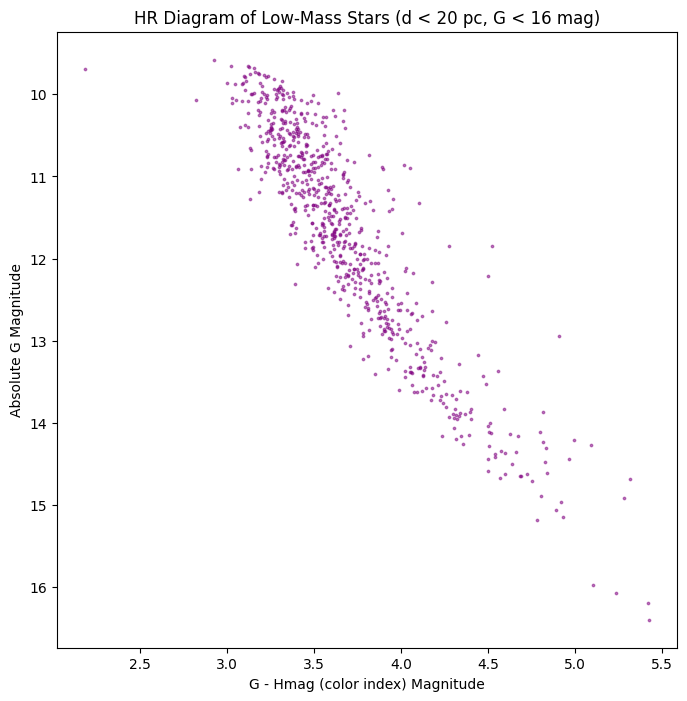

In [12]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# read data
file = pd.read_csv("TESS_M=0.4_RP=15.csv")

# distance conversion to pc 
file['distance_pc'] = 1000 / file['parallax']  # parallax in mas to distance in parsecs

# mask of magnitude limit from 0-16 and distance no greater than 20 pc
mask = (
    (file['phot_g_mean_mag'] > 0) &
    (file['phot_g_mean_mag'] < 16) &
    (file['distance_pc'] < 20)
)
file = file[mask]

#x-axis color index for G - H Mag
color = file['phot_g_mean_mag'] - file['Hmag'] # optical to deeper IR;  G-H moves more to the right since H is redder 
# good for very cool stars

# convert to absolute mag ; G - 5log_10 d + 5
gmag_ab = file['phot_g_mean_mag'] - 5 * np.log10(file['distance_pc']) + 5

# HR diagram plot
plt.figure(figsize=(8, 8))
plt.scatter(color, gmag_ab, s=3, alpha=0.5, c='purple')

plt.gca().invert_yaxis()  # magnitude scale is inverted
plt.xlabel("G - Hmag (color index) Magnitude")
plt.ylabel("Absolute G Magnitude")
plt.title("HR Diagram of Low-Mass Stars (d < 20 pc, G < 16 mag)")
plt.show()

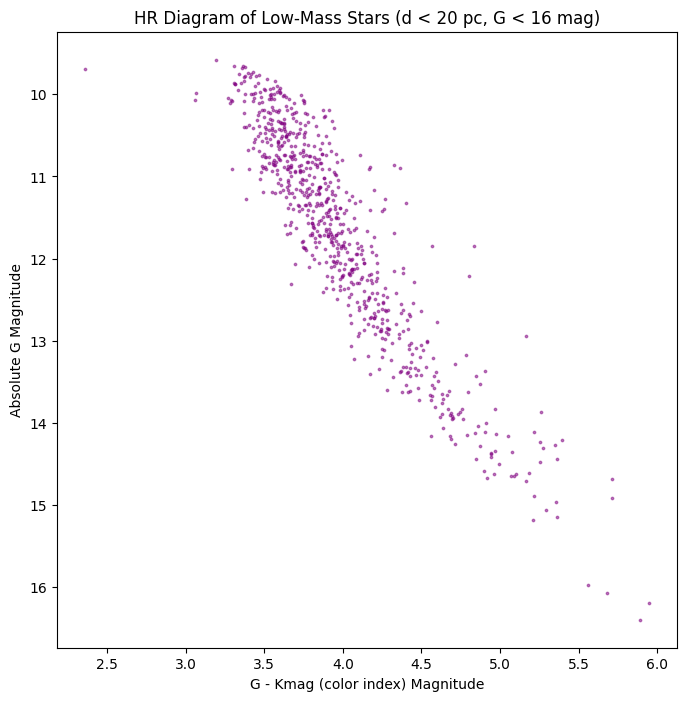

In [14]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# read data
file = pd.read_csv("TESS_M=0.4_RP=15.csv")

# distance conversion to pc 
file['distance_pc'] = 1000 / file['parallax']  # parallax in mas to distance in parsecs

# mask of magnitude limit from 0-16 and distance no greater than 20 pc
mask = (
    (file['phot_g_mean_mag'] > 0) &
    (file['phot_g_mean_mag'] < 16) &
    (file['distance_pc'] < 20)
)
file = file[mask]

#x-axis color index for G - K Mag
color = file['phot_g_mean_mag'] - file['Kmag'] # optical to deeper IR (bit farther);  G-H moves more to the right since H is redder 
# best for cool stars

# convert to absolute mag ; G - 5log_10 d + 5
gmag_ab = file['phot_g_mean_mag'] - 5 * np.log10(file['distance_pc']) + 5

# HR diagram plot
plt.figure(figsize=(8, 8))
plt.scatter(color, gmag_ab, s=3, alpha=0.5, c='purple')

plt.gca().invert_yaxis()  # magnitude scale is inverted
plt.xlabel("G - Kmag (color index) Magnitude")
plt.ylabel("Absolute G Magnitude")
plt.title("HR Diagram of Low-Mass Stars (d < 20 pc, G < 16 mag)")
plt.show()

In [29]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

from astropy.coordinates import SkyCoord
import astropy.units as u

In [31]:
# read data
file = pd.read_csv("TESS_M=0.4_RP=15.csv")

# compute distance in pc (Gaia parallax is in mas)
distance_pc = 1000 / file['parallax']

#convert RA/DEC to galactic coordinates (l,b) using astropy
coords = SkyCoord(ra=file['ra'].values * u.deg,
                  dec=file['dec'].values * u.deg,
                  frame='icrs')
#new l,b coords
file['l'] = coords.galactic.l.degree
file['b'] = coords.galactic.b.degree

#galactic lat. in degrees
b = file['b'].values 

Number of objects with b > 20°: 119129


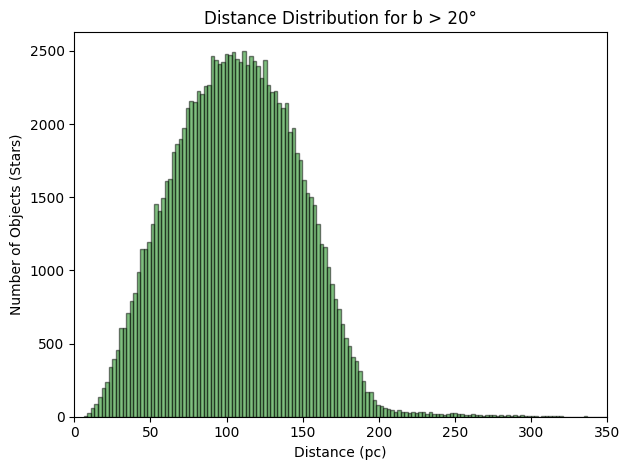

In [32]:
# b > 20 deg (off the galactic plane)
mask_off_plane = (b > 20) | (b < -20)
distance_off_plane = distance_pc[mask_off_plane]

N_off = len(distance_off_plane)
print("Number of objects with b > 20°:", N_off)

plt.hist(distance_off_plane, bins=n_bins, color='green', alpha=0.5, edgecolor='black')
plt.xlabel("Distance (pc)")
plt.xlim(0, 350)
plt.ylabel("Number of Objects (Stars)")
plt.title("Distance Distribution for b > 20°")
plt.tight_layout()
plt.show()

Number of objects with b ≤ 20°: 21684


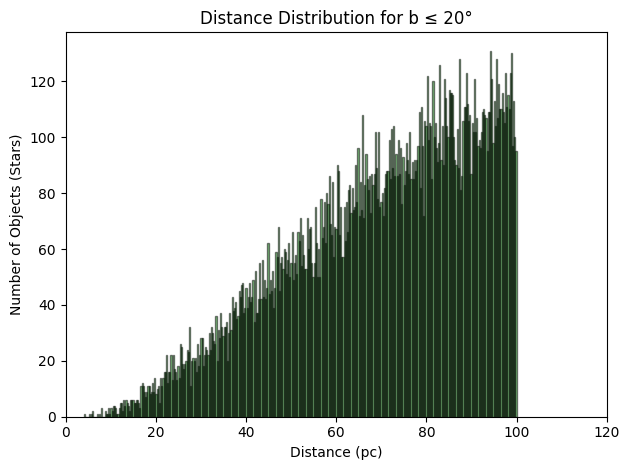

In [36]:
# b < 20 (in the galactic plane)
mask_in_plane = (b <= 20) & (b >= -20)
distance_in_plane = distance_pc[mask_in_plane]

N_in = len(distance_in_plane)
print("Number of objects with b ≤ 20°:", N_in)

plt.hist(distance_in_plane, bins=n_bins, color='green', alpha=0.5, edgecolor='black')
plt.xlabel("Distance (pc)")
plt.xlim(0, 120)
plt.ylabel("Number of Objects (Stars)")
plt.title("Distance Distribution for b ≤ 20°")
plt.tight_layout()
plt.show()

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

# Read data
file = pd.read_csv("TESS_M=0.4_RP=15.csv")

# Drop rows with missing magnitudes
file = file.dropna(subset=['Tmag', 'phot_rp_mean_mag'])

# Scatter plot: TESS T mag vs Gaia RP mag
plt.figure(figsize=(8, 8))
plt.scatter(
    file['Tmag'],
    file['phot_rp_mean_mag'],
    s=1,
    alpha=0.2,
    c='purple'
)

# Invert both axes (magnitudes: brighter = smaller)
plt.gca().invert_xaxis()
plt.gca().invert_yaxis()

plt.xlabel("TESS T Magnitude")
plt.ylabel("Gaia RP Magnitude")
plt.title("TESS T Magnitude vs Gaia RP Magnitude")

plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


KeyError: ['Tmag']

In [4]:
%matplotlib inline
import lightkurve as lk

lk.search_targetpixelfile("Gaia DR3 769456276704128", mission="TESS", author="SPOC")

#,mission,year,author,exptime,target_name,distance
,,,,s,,arcsec
0,TESS Sector 04,2018,SPOC,120,328401671,0.0
1,TESS Sector 31,2020,SPOC,120,328401671,0.0


In [12]:
search_result = lk.search_lightcurve("Gaia DR3 769456276704128", mission="TESS", author="SPOC")
search_result

#,mission,year,author,exptime,target_name,distance
,,,,s,,arcsec
0,TESS Sector 04,2018,SPOC,120,328401671,0.0
1,TESS Sector 31,2020,SPOC,120,328401671,0.0


In [10]:
search_result[0]

#,mission,year,author,exptime,target_name,distance
,,,,s,,arcsec
0,TESS Sector 04,2018,SPOC,120,328401671,0.0


In [15]:
lcf = search_result[0].download()
lcf

time,flux,flux_err,timecorr,cadenceno,centroid_col,centroid_row,sap_flux,sap_flux_err,sap_bkg,sap_bkg_err,pdcsap_flux,pdcsap_flux_err,quality,psf_centr1,psf_centr1_err,psf_centr2,psf_centr2_err,mom_centr1,mom_centr1_err,mom_centr2,mom_centr2_err,pos_corr1,pos_corr2
,electron / s,electron / s,d,,pix,pix,electron / s,electron / s,electron / s,electron / s,electron / s,electron / s,,pix,pix,pix,pix,pix,pix,pix,pix,pix,pix
Time,float32,float32,float32,int32,float64,float64,float32,float32,float32,float32,float32,float32,int32,float64,float32,float64,float32,float64,float32,float64,float32,float32,float32
1410.9078867947098,8.5420343e+02,6.6443033e+00,5.2594487e-03,132082,924.74270,1539.61882,6.0974213e+02,4.7450213e+00,8.0415900e+02,2.1866493e+00,8.5420343e+02,6.6443033e+00,0,———,———,———,———,924.74270,5.4820799e-03,1539.61882,3.5525395e-03,-1.5363242e-01,1.6808777e-01
1410.9092757351864,8.4414349e+02,6.6330400e+00,5.2595008e-03,132083,924.75163,1539.61634,6.0235199e+02,4.7369776e+00,8.0375781e+02,2.1816852e+00,8.4414349e+02,6.6330400e+00,0,———,———,———,———,924.75163,5.5424585e-03,1539.61634,3.5899314e-03,-1.5262674e-01,1.6838431e-01
1410.910664675663,8.4434570e+02,6.6255517e+00,5.2595530e-03,132084,924.74935,1539.61727,6.0294055e+02,4.7316294e+00,8.0139893e+02,2.1805947e+00,8.4434570e+02,6.6255517e+00,0,———,———,———,———,924.74935,5.5209533e-03,1539.61727,3.5818091e-03,-1.5173505e-01,1.6520785e-01
1410.9120536166045,8.3982434e+02,6.6360903e+00,5.2596056e-03,132085,924.73400,1539.61561,5.9930658e+02,4.7391558e+00,8.0802612e+02,2.1894178e+00,8.3982434e+02,6.6360903e+00,0,———,———,———,———,924.73400,5.5717332e-03,1539.61561,3.6074209e-03,-1.5516743e-01,1.6842282e-01
1410.9134425570803,8.3662701e+02,6.6256824e+00,5.2596577e-03,132086,924.74915,1539.61454,5.9723132e+02,4.7317228e+00,8.0459595e+02,2.1822090e+00,8.3662701e+02,6.6256824e+00,0,———,———,———,———,924.74915,5.5726445e-03,1539.61454,3.6152056e-03,-1.5225431e-01,1.6406392e-01
1410.9148314975569,8.5303973e+02,6.6396513e+00,5.2597099e-03,132087,924.75063,1539.61317,6.0963397e+02,4.7416987e+00,8.0329016e+02,2.1792562e+00,8.5303973e+02,6.6396513e+00,0,———,———,———,———,924.75063,5.4647536e-03,1539.61317,3.5502554e-03,-1.4882642e-01,1.6000381e-01
1410.9162204380334,8.5409827e+02,6.6509037e+00,5.2597621e-03,132088,924.75145,1539.61808,6.0970032e+02,4.7497344e+00,8.0391461e+02,2.1866467e+00,8.5409827e+02,6.6509037e+00,0,———,———,———,———,924.75145,5.4649548e-03,1539.61808,3.5569258e-03,-1.5506613e-01,1.6860464e-01
1410.9176093785093,8.5493811e+02,6.6418247e+00,5.2598142e-03,132089,924.75620,1539.61349,6.1045959e+02,4.7432508e+00,8.0417950e+02,2.1816566e+00,8.5493811e+02,6.6418247e+00,0,———,———,———,———,924.75620,5.4604178e-03,1539.61349,3.5460941e-03,-1.5280442e-01,1.6432157e-01


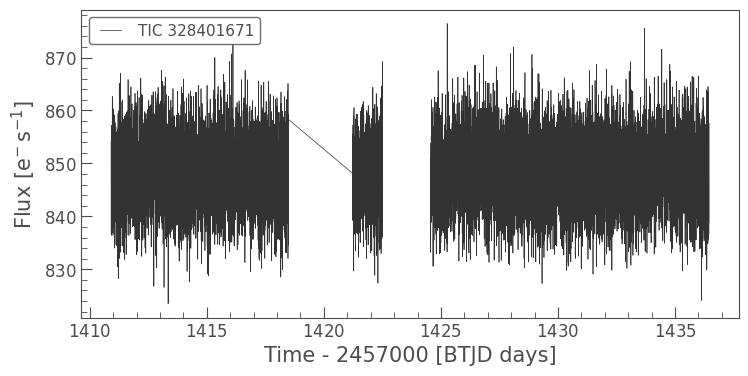

In [16]:
lcf.plot();

In [29]:
%matplotlib inline
import lightkurve as lk

# sanity check
search_result = lk.search_lightcurve("Gaia DR3 373838214051410816", mission="TESS", author="SPOC")
search_result
search_result[0]
lcf = search_result[0].download()
tessmag = lcf.meta.get("TESSMAG")
print(f"TESS MAG:", tessmag)


TESS MAG: 11.28890038


### Code that adds Tess mag to spreadsheet for d<20 and 0 < G < 16

In [17]:
import pandas as pd
import lightkurve as lk

# load csv
file = pd.read_csv("TESS_M=0.4_RP=15.csv")

# convert to pc
file["distance_pc"] = 1000.0 / file["parallax"]

# mask: 0 < G < 16 and distance < 20 pc
mask = (
    (file["phot_g_mean_mag"] > 0) &
    (file["phot_g_mean_mag"] < 16) &
    (file["distance_pc"] <= 20)
)

file = file[mask].reset_index(drop=True)

print("Total targets in original file:", len(pd.read_csv("TESS_M=0.4_RP=15.csv")))
print("Targets after Gaia filtering (0<G<16, d<=20 pc):", len(file))

# new column for tess mag
file["Tess_mag"] = None


# loop targets for Tess mag (SPOC)
for i, row in enumerate(file.itertuples(index=False), start=1):
    gaia_id = row.source_id
    ra = row.ra
    dec = row.dec

    print(f"{i}/{len(file)}  Gaia DR3 {gaia_id}  (RA={ra}, DEC={dec})")

    try:
        coord = f"{ra} {dec}"

        # Query SPOC light curves near this coordinate
        sr = lk.search_lightcurve(coord, mission="TESS", author="SPOC")

        if len(sr) == 0:
            print("  No SPOC data")
            continue

        lcf = sr[0].download()
        tessmag = lcf.meta.get("TESSMAG")
        print(f"  TESSMAG = {tessmag}")

        file.loc[file["source_id"] == gaia_id, "Tess_mag"] = tessmag

    except Exception as e:
        print(f"  Error for {gaia_id}: {e}")
        continue

outname = "TESS_Gmag0_16_d20pc_WITH_TESSMAG.csv"
file.to_csv(outname, index=False)
print(f"Saved file: {outname}")


Total targets in original file: 140813
Targets after Gaia filtering (0<G<16, d<=20 pc): 736
1/736  Gaia DR3 769456276704128  (RA=47.51489911594037, DEC=2.572769511017299)
  No SPOC data
2/736  Gaia DR3 16302463200535040  (RA=50.8422709188759, DEC=11.686387390947743)
  TESSMAG = 9.90711975
3/736  Gaia DR3 18986817760556416  (RA=39.82435828918509, DEC=7.470816071340625)


No data found for target "39.82435828918509 7.470816071340625".


  No SPOC data
4/736  Gaia DR3 35398295820372864  (RA=43.358915254728714, DEC=17.407883277761023)


No data found for target "43.358915254728714 17.407883277761023".


  No SPOC data
5/736  Gaia DR3 57739208163471744  (RA=51.68738385482385, DEC=19.243802626944703)
  TESSMAG = 11.92259979
6/736  Gaia DR3 68553931516671488  (RA=54.87437762176911, DEC=24.96824115907829)
  TESSMAG = 10.37059975
7/736  Gaia DR3 72117556076986368  (RA=33.98650746472387, DEC=10.254962202598763)


...

  No SPOC data
732/736  Gaia DR3 6116110468338455680  (RA=214.35558247321825, DEC=-40.304202316175186)


No data found for target "214.35558247321825 -40.304202316175186".


  No SPOC data
733/736  Gaia DR3 6143175943486753152  (RA=182.48992008073932, DEC=-46.19264116008711)


No data found for target "182.48992008073932 -46.19264116008711".


  No SPOC data
734/736  Gaia DR3 6725832095922016256  (RA=273.3347119890693, DEC=-39.84395218207264)
  TESSMAG = 10.53909969
735/736  Gaia DR3 6734485286788609664  (RA=277.3507091117809, DEC=-34.96362316023356)
  TESSMAG = 9.55978012
736/736  Gaia DR3 6759481141756109056  (RA=290.376709235217, DEC=-29.2629248637208)
  TESSMAG = 13.80889988
Saved file: TESS_Gmag0_16_d20pc_WITH_TESSMAG.csv


### Plotting Tmag vs Rp for d<20, 0 < G < 16

Total targets in parameter: 736
Targets with TESS mag: 320


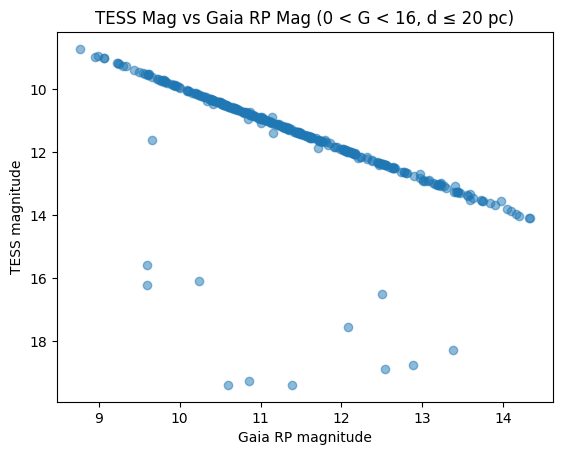

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# load file
df = pd.read_csv("TESS_Gmag0_16_d20pc_w_TESSMAG.csv")

# only use rows that have tess mag
df_plot = df[df["Tess_mag"].notna()].copy()

# T mag vs Rp mag
x = "phot_rp_mean_mag"  
y = "Tess_mag"           

plt.figure()
plt.scatter(df_plot[x], df_plot[y], alpha = 0.5)
plt.title("TESS Mag vs Gaia RP Mag (0 < G < 16, d ≤ 20 pc)")
plt.xlabel("Gaia RP magnitude")
plt.ylabel("TESS magnitude")
plt.gca().invert_yaxis() 
plt.show()

print("Total targets in parameter:", len(df))
print("Targets with TESS mag:", len(df_plot))


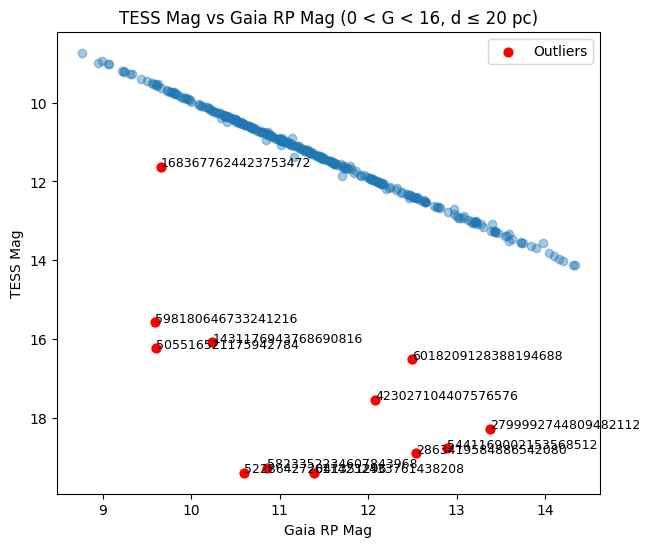

Outliers:
               source_id  phot_rp_mean_mag   Tess_mag     resid
18    598180646733241216          9.594552  15.578100  5.732575
102  1431176943768690816         10.240054  16.090300  5.636728
134  1683677624423753472          9.658345  11.624000  1.718383
199  2799992744809482112         13.384194  18.285200  4.869931
208  2863419584886542080         12.537745  18.906200  6.288264
395  6114232433761438208         11.387139  19.393801  7.859705
499   423027104407576576         12.079866  17.547300  5.360674
508   505516521175942784          9.599484  16.231001  6.380829
510   522864272041351296         10.594085  19.399200  8.612142
677  5441169002153568512         12.890629  18.776699  5.826356
704  5823352234607843968         10.851352  19.275400  8.246003
720  6018209128388194688         12.498873  16.522301  3.940982


In [16]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# load file
df = pd.read_csv("TESS_Gmag0_16_d20pc_w_TESSMAG.csv")
df_plot = df[df["Tess_mag"].notna()].copy()

x = df_plot["phot_rp_mean_mag"].values
y = df_plot["Tess_mag"].values

# fit line
coeff = np.polyfit(x, y, 1)
y_fit = np.polyval(coeff, x)

# residuals
resid = y - y_fit
df_plot["resid"] = resid

# choose threshold (e.g. > 1 mag off trend)
outliers = df_plot[np.abs(df_plot["resid"]) > 1.0]

# plot
plt.figure(figsize=(7,6))
plt.scatter(x, y, alpha=0.4)
plt.scatter(outliers["phot_rp_mean_mag"], outliers["Tess_mag"], 
            color="red", s=40, label="Outliers")

# label them
for _, row in outliers.iterrows():
    plt.text(row["phot_rp_mean_mag"], row["Tess_mag"],
             str(row["source_id"]), fontsize=9)

plt.gca().invert_yaxis()
plt.title("TESS Mag vs Gaia RP Mag (0 < G < 16, d ≤ 20 pc)")
plt.xlabel("Gaia RP Mag")
plt.ylabel("TESS Mag")
plt.legend()
plt.show()

print("Outliers:")
print(outliers[["source_id","phot_rp_mean_mag","Tess_mag","resid"]])
